In [4]:
### Here we will create the same heatmap done before (but with23 prot rather than 17)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [5]:
list_p = ['PROC.3758.68', 'HIST1H1C.2987.37', 'ASB9.19601.15',
       'CPLX2.15321.8', 'HIST2H2BE.14143.8', 'AFM.4763.31', 'PTH.5954.62',
       'SERPINA7.2706.69', 'RAP2A.9885.41', 'ADSSL1.13998.26',
       'FCN2.13717.15', 'ADSL.5023.23', 'CLIC5.12475.48',
       'ALDH2.18381.16', 'PLTP.15475.4', 'CLEC1B.4332.6', 'TGM3.4471.50',
       'CCL22.3508.78', 'IL1RL1.4234.8', 'UBA2.12500.88',
       'SERPINF1.9211.19', 'IL19.3035.80', 'PDLIM4.12387.7']

# read data
clin = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/clin_ready.csv', header = 0, index_col=0)
prot = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/raw_data_proteins_filtered.csv',header = 0, index_col = 0)
prot_list = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/prot_filtered.csv', header = 0, index_col=0)

prot = prot.filter(prot_list.iloc[:,0], axis = 1)
prot = prot.drop(labels = [1578], axis = 0)
clin = clin.drop(labels = [1578], axis = 0)
print('clin:', clin.shape)
print('prot:', prot.shape)

clin: (414, 38)
prot: (414, 4979)


In [6]:
X = StandardScaler().fit_transform(prot)
df_scaled = pd.DataFrame(X)
df_scaled.columns = prot.columns
df_scaled.index = prot.index


In [84]:
# prot 23
prot_23 = df_scaled.filter(items = list_p, axis = 1)
severity = [1 if i >24 else 0 for i in clin.iss]
lut = {0:"plum",
       1: "teal"}
col_colors = pd.Series(severity, index = clin.index).map(lut)

{0: 'plum', 1: 'teal'}

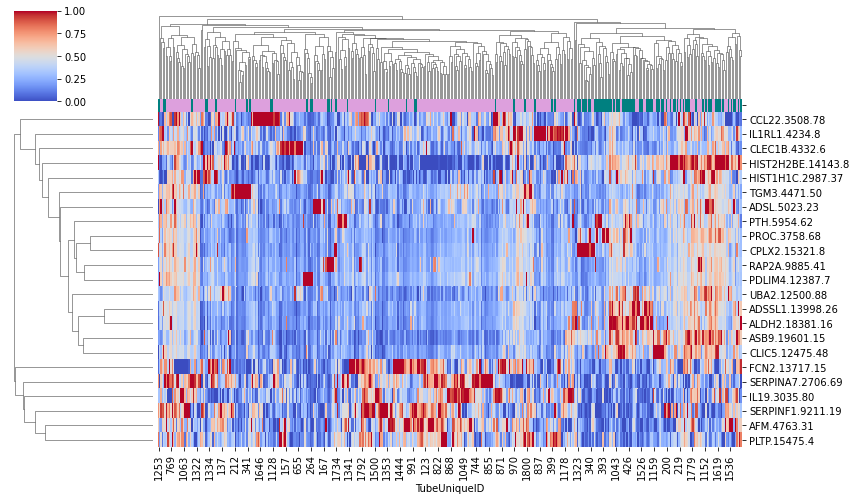

In [101]:
### clustermap
sns.clustermap(prot_23.T, standard_scale=1, cmap = 'coolwarm', figsize = (12, 7), col_colors=col_colors, method = 'average', row_cluster=True)

